In [ ]:
from __future__ import annotations

import json
import random
import sys
import time
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from tqdm import tqdm


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "churn_pipeline").exists() and (p / "churn-prediction-25-26").exists():
            return p
    return start


ROOT = _find_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

from churn_pipeline.dataset_builder import build_datasets_cli  # noqa: E402
from churn_pipeline.transformer_user_day import (  # noqa: E402
    ChurnTransformerUserDay,
    TrainingConfig,
    UserDayTableSequenceDataset,
    UserSequenceDataset,
    collate_batch,
    make_dataloaders,
    make_dataloaders_from_user_day_tables,
    predict_proba,
    train_model,
 )

## 1) Configuration: cutoffs, label, feature window, Transformer params

In [ ]:
# Data paths (self-contained in this folder: ROOT/churn-prediction-25-26)
COMPETITION_DIR = ROOT / "churn-prediction-25-26"
TRAIN_PATH = COMPETITION_DIR / "train.parquet"
TEST_PATH = COMPETITION_DIR / "test.parquet"
EXAMPLE_SUB = COMPETITION_DIR / "example_submission.csv"

# rolling cutoffs (start coarse to validate the pipeline, then densify)
CUTOFF_START = "2018-10-01"
CUTOFF_END = "2018-11-10"
CUTOFF_FREQ = "1D"  # "1D" | "2D" | "3D" | ...
CUT_OFFS = pd.date_range(CUTOFF_START, CUTOFF_END, freq=CUTOFF_FREQ)

# label
LABEL_MODE = "horizon"  # "horizon" | "ever"
HORIZON_DAYS = 10

# feature window: number of recent days (align with Transformer max_seq_len)
LOOKBACK_DAYS = 51

# leakage-prevention filters (keep consistent with the main notebook)
EXCLUDE_PAGES = "Cancellation Confirmation,Cancel"
EXCLUDE_AUTH_VALUES = "Cancelled"

# build parameters
DROP_LAST_K_EVENTS = 0
FULL_CALENDAR = True
VAL_PROB_LOW = 0.8
VAL_PROB_HIGH = 1.0
SPLIT_SEED = "split_v1"

# Performance/cache (kept inside this folder for portability)
CACHE_DIR = ROOT / ".cache" / "user_day_features"
OUTPUT_BASE_DIR = ROOT / "data" / "processed"
BATCH_SIZE = 1_000_000
FORCE_RECOMPUTE = False

# Transformer training config
config = TrainingConfig(
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.5,
    max_seq_len=int(LOOKBACK_DAYS),
    batch_size=256,
    lr=1e-4,
    weight_decay=7e-3,
    epochs=25,
    use_cosine_decay=True,
    eta_min_factor=0.1,
    warmup_epochs=1,
    use_focal_loss=True,
    focal_gamma=2.0,
    early_stop_patience=3,
    early_stop_min_delta=0.0,
    pooling="mean",
 )

SEEDS = [42, 2021, 7]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT=", ROOT)
print("cutoffs=", len(CUT_OFFS), CUT_OFFS.min().date(), "->", CUT_OFFS.max().date())
print("device=", device)
print("max_seq_len=", config.max_seq_len)

cutoffs= 41 2018-10-01 -> 2018-11-10
device= cuda
max_seq_len= 51


## 2) Build rolling train/val (concatenate multiple cutoff snapshots)

Outputs:
- `train_ud_all` / `val_ud_all`: concatenated user-day table (userId has a `|cutoff` suffix to avoid collisions)
- `labels_dict`: train+val labels keyed by the same suffixed userId

In [3]:
t0 = time.time()

all_train_ud = []
all_val_ud = []
all_labels = []

for cutoff in tqdm(CUT_OFFS, desc='build rolling cutoffs'):
    cutoff_str = str(pd.Timestamp(cutoff).date())
    paths = build_datasets_cli(
        train_path=str(TRAIN_PATH),
        test_path=str(TEST_PATH),
        output_dir=None,
        output_base_dir=str(OUTPUT_BASE_DIR),
        cache_dir=str(CACHE_DIR),
        cutoff_time=cutoff_str,
        horizon_days=int(HORIZON_DAYS),
        label_mode=str(LABEL_MODE),
        drop_last_k_events=int(DROP_LAST_K_EVENTS),
        exclude_pages=str(EXCLUDE_PAGES),
        exclude_auth_values=str(EXCLUDE_AUTH_VALUES),
        val_prob_low=float(VAL_PROB_LOW),
        val_prob_high=float(VAL_PROB_HIGH),
        split_seed=str(SPLIT_SEED),
        batch_size=int(BATCH_SIZE),
        full_calendar=bool(FULL_CALENDAR),
        force_recompute=bool(FORCE_RECOMPUTE),
        verbose=False,
    )

    train_ud = pd.read_parquet(paths['train_features'])
    val_ud = pd.read_parquet(paths['val_features'])
    train_lab = pd.read_parquet(paths['train_labels'])[['userId', 'label']]
    val_lab = pd.read_parquet(paths['val_labels'])[['userId', 'label']]

    end_day = pd.Timestamp(cutoff).normalize() - pd.Timedelta(days=1)
    start_day = end_day - pd.Timedelta(days=int(LOOKBACK_DAYS) - 1)

    def _slice(df: pd.DataFrame) -> pd.DataFrame:
        d = pd.to_datetime(df['day']).dt.normalize()
        return df.loc[(d >= start_day) & (d <= end_day)].copy()

    train_ud = _slice(train_ud)
    val_ud = _slice(val_ud)

    suffix = '|' + cutoff_str
    train_ud['userId'] = train_ud['userId'].astype(str) + suffix
    val_ud['userId'] = val_ud['userId'].astype(str) + suffix
    train_lab['userId'] = train_lab['userId'].astype(str) + suffix
    val_lab['userId'] = val_lab['userId'].astype(str) + suffix

    all_train_ud.append(train_ud)
    all_val_ud.append(val_ud)
    all_labels.append(pd.concat([train_lab, val_lab], axis=0, ignore_index=True))

train_ud_all = pd.concat(all_train_ud, axis=0, ignore_index=True)
val_ud_all = pd.concat(all_val_ud, axis=0, ignore_index=True)
labels_all = pd.concat(all_labels, axis=0, ignore_index=True)

labels_dict = {str(uid): int(y) for uid, y in zip(labels_all['userId'].astype(str), labels_all['label'].astype(int))}

print('train_ud_all', train_ud_all.shape, 'val_ud_all', val_ud_all.shape)
print('labels_all', labels_all.shape, 'unique labels keys', len(labels_dict))
print('seconds', round(time.time() - t0, 2))
(train_ud_all.head(), val_ud_all.head(), labels_all.head())

build rolling cutoffs: 100%|██████████| 41/41 [01:01<00:00,  1.50s/it]


train_ud_all (12523860, 132) val_ud_all (3170940, 132)
labels_all (784740, 2) unique labels keys 784740
seconds 62.63


(               userId        day  d_events  d_sessions  d_pages_unique  \
 0  1000025|2018-10-02 2018-10-01         0           0               0   
 1  1000035|2018-10-02 2018-10-01         0           0               0   
 2  1000083|2018-10-02 2018-10-01        14           1               3   
 3  1000103|2018-10-02 2018-10-01         0           0               0   
 4  1000164|2018-10-02 2018-10-01         2           1               2   
 
    d_active_hours  d_first_hour  d_last_hour  d_span_sec  \
 0               0            -1           -1         0.0   
 1               0            -1           -1         0.0   
 2               3             5           11     20881.0   
 3               0            -1           -1         0.0   
 4               1            17           17        94.0   
 
    d_mean_gap_proxy_sec  ...  x_active_streak  d_events_per_session  \
 0              0.000000  ...                0                   0.0   
 1              0.000000  ...       

In [4]:
# sanity check: ensure new features appear in rolling train/val
expected_new = [
    # older engineered cols
    "u_tenure_days",
    "d_song_bucket_unique",
    "d_artist_bucket_unique",
    "d_song_repeat_rate",
    "d_artist_repeat_rate",
    # rhythm / burstiness proxies
    "d_span_sec",
    "d_mean_gap_proxy_sec",
    "d_inactive_hours",
    "d_events_per_active_hour",
    "d_sessions_per_active_hour",
    "d_nextsong_per_active_hour",
    # session structure
    "d_sess_events_max",
    "d_sess_dur_sec_sum",
    "d_sess_dur_sec_mean",
    "d_sess_dur_sec_max",
    # diversity / concentration
    "d_page_entropy_norm",
    "d_page_simpson",
    "d_page_top1_share",
    "d_status_entropy_norm",
    "d_status_simpson",
    "d_status_top1_share",
    "d_method_entropy_norm",
    "d_method_simpson",
    "d_method_top1_share",
    "d_auth_entropy_norm",
    "d_auth_simpson",
    "d_auth_top1_share",
    # multi-scale roll windows
    "x_roll3_events_sum",
    "x_roll3_events_mean",
    "x_roll3_nextsong_sum",
    "x_roll3_nextsong_mean",
    "x_roll3_active_days",
    "x_roll7_events_sum",
    "x_roll7_events_mean",
    "x_roll7_nextsong_sum",
    "x_roll7_nextsong_mean",
    "x_roll7_active_days",
    "x_roll14_events_sum",
    "x_roll14_events_mean",
    "x_roll14_nextsong_sum",
    "x_roll14_nextsong_mean",
    "x_roll14_active_days",
    "x_roll28_events_sum",
    "x_roll28_events_mean",
    "x_roll28_nextsong_sum",
    "x_roll28_nextsong_mean",
    "x_roll28_active_days",
    # paid temporal / rates
    "x_roll7_paid_ratio_mean",
    "x_roll14_paid_ratio_mean",
    "x_roll28_paid_ratio_mean",
    "x_roll7_paid_days",
    "x_roll14_paid_days",
    "x_days_since_last_paid",
    "x_paid_streak",
    # level switch dynamics
    "x_roll3_level_switch_cnt",
    "x_roll7_level_switch_cnt",
    "x_roll14_level_switch_cnt",
    "x_roll28_level_switch_cnt",
    "x_days_since_last_level_switch",
    # errors/pages rolling
    "x_roll7_error_rate_mean",
    "x_roll14_error_rate_mean",
    "x_roll28_error_rate_mean",
    "x_roll7_pages_unique_mean",
    "x_roll14_pages_unique_mean",
    "x_roll28_pages_unique_mean",
    # intensity / volatility
    "d_events_per_session",
    "d_nextsong_per_session",
    "x_roll7_std_events",
    "x_roll7_std_listen_sec_mean",
    # calendar
    "d_day_of_week",
    # legacy trend/state names kept for compatibility
    "x_trend7_events",
    "x_trend7_nextsong",
    "x_days_since_last_active",
    "x_active_streak",
    # relative change features
    "x_today_over_roll7_events_mean",
    "x_today_over_roll7_nextsong_mean",
    "x_roll7_minus_roll28_events_mean",
    "x_roll7_minus_roll28_nextsong_mean",
]
missing_train = [c for c in expected_new if c not in set(train_ud_all.columns)]
missing_val = [c for c in expected_new if c not in set(val_ud_all.columns)]
print("missing in train_ud_all:", missing_train)
print("missing in val_ud_all:", missing_val)
print("num feature cols (train):", len([c for c in train_ud_all.columns if c not in {"userId","day"}]))

missing in train_ud_all: []
missing in val_ud_all: []
num feature cols (train): 130


## 3) Build test with a fixed cutoff (for submission)

Note: test is not built in a rolling way; we use a single cutoff (usually the last day).

In [5]:
SUBMISSION_CUTOFF = str(pd.Timestamp(CUTOFF_END).date())

sub_paths = build_datasets_cli(
    train_path=str(TRAIN_PATH),
    test_path=str(TEST_PATH),
    output_dir=None,
    output_base_dir=str(OUTPUT_BASE_DIR),
    cache_dir=str(CACHE_DIR),
    cutoff_time=SUBMISSION_CUTOFF,
    horizon_days=int(HORIZON_DAYS),
    label_mode=str(LABEL_MODE),
    drop_last_k_events=int(DROP_LAST_K_EVENTS),
    exclude_pages=str(EXCLUDE_PAGES),
    exclude_auth_values=str(EXCLUDE_AUTH_VALUES),
    val_prob_low=float(VAL_PROB_LOW),
    val_prob_high=float(VAL_PROB_HIGH),
    split_seed=str(SPLIT_SEED),
    batch_size=int(BATCH_SIZE),
    full_calendar=bool(FULL_CALENDAR),
    force_recompute=bool(FORCE_RECOMPUTE),
    verbose=False,
)

test_ud = pd.read_parquet(sub_paths['test_features'])
cutoff_ts = pd.Timestamp(SUBMISSION_CUTOFF).normalize()
end_day = cutoff_ts - pd.Timedelta(days=1)
start_day = end_day - pd.Timedelta(days=int(LOOKBACK_DAYS) - 1)
d = pd.to_datetime(test_ud['day']).dt.normalize()
test_ud = test_ud.loc[(d >= start_day) & (d <= end_day)].copy()

print('test_ud', test_ud.shape, 'window', str(start_day.date()), '->', str(end_day.date()))
test_ud.head()

test_ud (116160, 132) window 2018-09-20 -> 2018-11-09


,userId,day,d_events,d_sessions,d_pages_unique,d_active_hours,d_first_hour,d_last_hour,d_span_sec,d_mean_gap_proxy_sec,...,x_active_streak,d_events_per_session,d_nextsong_per_session,x_roll7_std_events,x_roll7_std_listen_sec_mean,d_day_of_week,x_today_over_roll7_events_mean,x_today_over_roll7_nextsong_mean,x_roll7_minus_roll28_events_mean,x_roll7_minus_roll28_nextsong_mean
0,1000655,2018-10-01,0,0,0,0,-1,-1,0.0,0.000000,...,0,0.0,0.0,0.000000,0.000000,0,0.0,0.000000,0.000000,0.000000
1,1000655,2018-10-02,0,0,0,0,-1,-1,0.0,0.000000,...,0,0.0,0.0,0.000000,0.000000,1,0.0,0.000000,0.000000,0.000000
2,1000655,2018-10-03,39,1,6,3,9,11,8274.0,217.736847,...,1,39.0,31.0,13.647158,96.482307,2,7.0,7.000000,4.178572,3.321428
3,1000655,2018-10-04,0,0,0,0,-1,-1,0.0,0.000000,...,0,0.0,0.0,13.647158,96.482307,3,0.0,0.000000,4.178572,3.321428
4,1000655,2018-10-05,31,1,7,2,22,23,6704.0,223.466660,...,1,31.0,23.0,15.955296,132.544189,4,3.1,2.981481,7.500000,5.785714


## 4) Numeric feature processing: drop constant cols + log1p/clip + StandardScaler

Follow the same logic as `transformer_train_predict.ipynb`:
- Feature columns: all columns except `userId`, `day`
- Drop: columns that are constant in rolling train
- log1p + clip: down-scale count-like features
- Fit scaler on rolling train only; apply to val/test

In [6]:
# Memory-lean numeric preprocessing (avoid big copies / temporary matrices)
# NOTE: this modifies train_ud_all/val_ud_all in-place through these references.
train_ud = train_ud_all
val_ud = val_ud_all

feature_cols = sorted([c for c in train_ud.columns if c not in {'userId', 'day'}])

# 1) drop train constant cols (cheaper than nunique on huge tables)
mins = train_ud[feature_cols].min(skipna=True)
maxs = train_ud[feature_cols].max(skipna=True)

keep_cols = []
for c in feature_cols:
    mn = mins.get(c)
    mx = maxs.get(c)
    # drop all-NaN or constant columns
    if (pd.isna(mn) and pd.isna(mx)) or (mn == mx):
        continue
    keep_cols.append(c)

drop_cols = [c for c in feature_cols if c not in set(keep_cols)]
print('drop constant cols:', len(drop_cols))
feature_cols = keep_cols

# 2) log1p + clip (count / sum-like features)
def _is_count_like(col: str) -> bool:
    if col.endswith('_cnt') or col.endswith('_sum'):
        return True
    if col.endswith('_active_days') or col.endswith('_paid_days'):
        return True
    if col in {
        'd_events',
        'd_sessions',
        'd_pages_unique',
        'd_active_hours',
        'd_nextsong_cnt',
        'd_listen_sec_sum',
        'd_level_free_cnt',
        'd_level_paid_cnt',
        'd_song_bucket_unique',
        'd_artist_bucket_unique',
        'x_roll7_events_sum',
        'x_roll7_nextsong_sum',
        'x_roll7_active_days',
        'x_roll3_active_days',
        'x_roll14_active_days',
        'x_roll28_active_days',
        'x_roll7_paid_days',
        'x_roll14_paid_days',
    }:
        return True
    return False

count_like = [c for c in feature_cols if _is_count_like(str(c))]
print('count_like:', len(count_like))

clip_q = 0.995

def _iter_blocks(items: list[str], block_size: int = 32):
    for i in range(0, len(items), int(block_size)):
        yield items[i : i + int(block_size)]

# compute clip_upper in small blocks to reduce peak memory during quantile
if count_like:
    _clip = {}
    for cols in _iter_blocks(count_like, block_size=32):
        q = train_ud[cols].quantile(clip_q, interpolation='linear')
        for c in cols:
            v = float(q.loc[c])
            # safety: clip upper shouldn't be negative for count-like features
            _clip[c] = max(0.0, v)
    clip_upper = pd.Series(_clip)
else:
    clip_upper = pd.Series(dtype=float)

def _ensure_float32(df: pd.DataFrame, cols: list[str]) -> None:
    for c in cols:
        if c in df.columns and df[c].dtype != np.float32:
            df[c] = df[c].astype(np.float32)

def _log1p_clip_inplace(df: pd.DataFrame) -> None:
    if not count_like:
        return
    _ensure_float32(df, count_like)
    for c in count_like:
        arr = df[c].to_numpy(copy=False)
        np.maximum(arr, 0.0, out=arr)
        up = float(clip_upper.get(c, np.inf))
        if np.isfinite(up):
            np.minimum(arr, up, out=arr)
        np.log1p(arr, out=arr)

_log1p_clip_inplace(train_ud)
_log1p_clip_inplace(val_ud)
_log1p_clip_inplace(test_ud)

# 3) Standardize (fit on train only) without building a huge dense matrix
# Compute mean/std column-wise (pandas does this efficiently)
mu = train_ud[feature_cols].mean(skipna=True)
std = train_ud[feature_cols].std(skipna=True, ddof=0)

means = mu.reindex(feature_cols).to_numpy(dtype=np.float32)
scales = std.reindex(feature_cols).to_numpy(dtype=np.float32)
scales = np.where(np.isfinite(scales) & (scales > 0), scales, 1.0).astype(np.float32)

def _standardize_inplace(df: pd.DataFrame) -> None:
    _ensure_float32(df, feature_cols)
    for c, m, s in zip(feature_cols, means, scales):
        arr = df[c].to_numpy(copy=False)
        np.subtract(arr, m, out=arr)
        np.divide(arr, s, out=arr)

_standardize_inplace(train_ud)
_standardize_inplace(val_ud)
_standardize_inplace(test_ud)

# Save scaler params for later serialization/repro
scaler_payload = {
    'mean_': means.astype(float).tolist(),
    'scale_': scales.astype(float).tolist(),
    'var_': (scales.astype(np.float64) ** 2).tolist(),
    'n_features_in_': int(len(feature_cols)),
}

(train_ud.shape, val_ud.shape, test_ud.shape, len(feature_cols))

drop constant cols: 7
count_like: 52


((12523860, 132), (3170940, 132), (116160, 132), 123)

## 5) Build sequence dataset + DataLoader

For each (suffixed) user, sort daily features by `day`, then take the most recent `max_seq_len` days as the Transformer input.

In [7]:
# Memory-lean: avoid `build_user_day_sequences()` which materializes a huge dict of arrays.
# Instead build lazy datasets from the user-day tables.

pos_weight = 7  # (you can compute from labels_all if you want)

# labels_dict is already built in section 2; no need to rebuild it here.

train_dataset = UserDayTableSequenceDataset(
    train_ud,
    feature_cols,
    config.max_seq_len,
    labels=labels_dict,
    assume_sorted=False,
 )
val_dataset = UserDayTableSequenceDataset(
    val_ud,
    feature_cols,
    config.max_seq_len,
    labels=labels_dict,
    assume_sorted=False,
 )
test_dataset = UserDayTableSequenceDataset(
    test_ud,
    feature_cols,
    config.max_seq_len,
    labels=None,
    assume_sorted=False,
 )

len(train_dataset), len(val_dataset), len(test_dataset)

(610920, 154680, 2904)

## 6) Train Transformer (multi-seed soft vote) + validate AUC

Outputs:
- `val_proba_mean`: mean probabilities on the val split (aligned by userId)
- `test_proba_mean`: mean probabilities on the test set (aligned by userId)

train_model:   0%|          | 0/25 [00:00<?, ?it/s]/Data/yuhan.wu/miniconda3/envs/py310/lib/python3.10/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
predict_proba: 100%|██████████| 12/12 [00:00<00:00, 107.01it/s]


0.7396064493710377

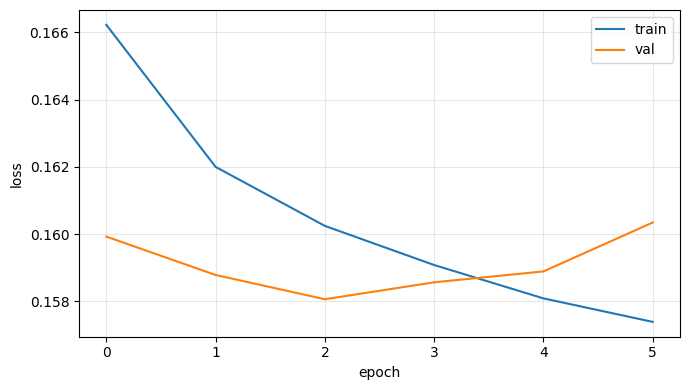

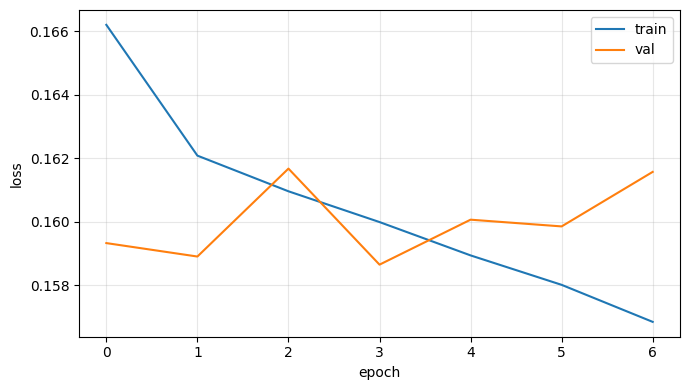

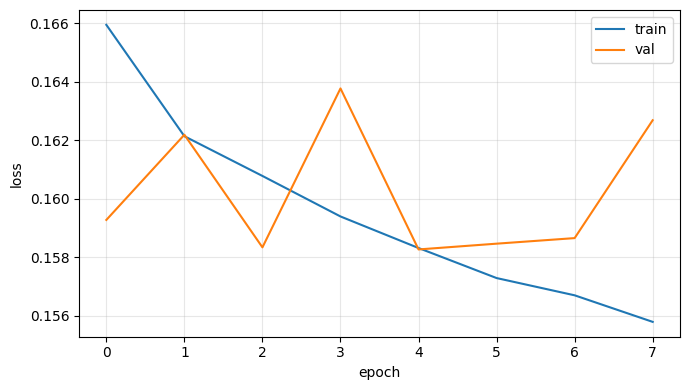

In [8]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


val_prob_by_seed = []
test_prob_by_seed = []
best_states = []

# Keep stable key order for ensembling/metrics
val_keys = list(val_dataset.user_ids)
test_keys = list(test_dataset.user_ids)

for seed in SEEDS:
    set_seed(int(seed))
    gen = torch.Generator()
    gen.manual_seed(int(seed))

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=config.num_workers,
        collate_fn=collate_batch,
        generator=gen,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        collate_fn=collate_batch,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        collate_fn=collate_batch,
    )

    model = ChurnTransformerUserDay(num_numeric=len(feature_cols), config=config).to(device)

    train_losses, val_losses, model, best_epoch, best_state = train_model(
        model,
        train_loader,
        val_loader,
        device,
        epochs=int(config.epochs),
        lr=float(config.lr),
        weight_decay=float(config.weight_decay),
        pos_weight=float(pos_weight),
        use_cosine_decay=bool(config.use_cosine_decay),
        eta_min_factor=float(config.eta_min_factor),
        warmup_epochs=int(config.warmup_epochs),
        use_focal_loss=bool(config.use_focal_loss),
        focal_gamma=float(config.focal_gamma),
        early_stop_patience=int(config.early_stop_patience),
        early_stop_min_delta=float(config.early_stop_min_delta),
    )

    val_probs = predict_proba(model, val_loader, device)
    test_probs = predict_proba(model, test_loader, device)

    val_prob_by_seed.append(val_probs)
    test_prob_by_seed.append(test_probs)
    best_states.append({'seed': int(seed), 'best_epoch': int(best_epoch), 'state_dict': best_state})
    import matplotlib.pyplot as plt 
    plt.figure(figsize=(7, 4))
    plt.plot( train_losses, label="train")
    plt.plot( val_losses, label="val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    # plt.title(out_png.stem)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
# Mean probabilities (soft vote)
val_proba_mean = np.mean([[d[k] for k in val_keys] for d in val_prob_by_seed], axis=0)
test_proba_mean = np.mean([[d[k] for k in test_keys] for d in test_prob_by_seed], axis=0)

y_val = np.array([labels_dict[k] for k in val_keys], dtype=int)
val_auc = float(roc_auc_score(y_val, val_proba_mean))
val_auc

## 7) Choose threshold (Balanced Accuracy)

In [9]:
thresholds = np.linspace(0.01, 0.99, 99)
bal_scores = [balanced_accuracy_score(y_val, (val_proba_mean >= t).astype(int)) for t in thresholds]
best_idx = int(np.argmax(bal_scores))
best_thr = float(thresholds[best_idx])
best_bal = float(bal_scores[best_idx])
best_thr, best_bal

(0.4, 0.6763692654288236)

## 8) Generate submission (id,target)

Note: test userIds do not have a cutoff suffix; they directly correspond to the competition `id`.

In [10]:
thr = float(best_thr)  # or set to 0.5

pred = pd.DataFrame({'id': np.array(test_keys, dtype=int), 'proba': test_proba_mean.astype(float)})
example = pd.read_csv(EXAMPLE_SUB)
out = example[['id']].merge(pred, on='id', how='left')
out['proba'] = out['proba'].fillna(0.0)
out['target'] = (out['proba'] >= thr).astype(int)
out = out[['id', 'target']]

print('test predicted positive rate:', float(out['target'].mean()))
out.head()

test predicted positive rate: 0.381198347107438


,id,target
0,1128274,0
1,1782451,0
2,1611542,0
3,1241663,1
4,1653104,1


## 9) Save artifacts and submission files (experiments/transformer_rolling/)

In [ ]:
run_name = (
    f"transformer_rolling_nb_cut{CUTOFF_START}-{CUTOFF_END}_{CUTOFF_FREQ}_"
    f"sub{SUBMISSION_CUTOFF}_h{HORIZON_DAYS}_lb{LOOKBACK_DAYS}_"
    f"s{len(SEEDS)}_thr{best_thr:.3f}"
)

# Write outputs under this folder (ROOT = portable experiment root)
ART_DIR = ROOT / "artifacts" / run_name
SUB_DIR = ROOT / "submissions"
ART_DIR.mkdir(parents=True, exist_ok=True)
SUB_DIR.mkdir(parents=True, exist_ok=True)

# Save: best_state per seed
for item in best_states:
    sd = {k: v for k, v in item.items() if k != "state_dict"}
    torch.save(item["state_dict"], ART_DIR / f"model_seed{item['seed']}.pt")
    (ART_DIR / f"model_seed{item['seed']}.json").write_text(
        json.dumps(sd, ensure_ascii=False, indent=2), encoding="utf-8"
    )

(ART_DIR / "training_config.json").write_text(
    json.dumps(asdict(config), ensure_ascii=False, indent=2), encoding="utf-8"
 )
(ART_DIR / "feature_columns.json").write_text(
    json.dumps(list(feature_cols), ensure_ascii=False, indent=2), encoding="utf-8"
 )

# Save scaler (parameters only; generated as scaler_payload in the previous preprocessing cell)
(ART_DIR / "scaler.json").write_text(
    json.dumps(scaler_payload, ensure_ascii=False, indent=2), encoding="utf-8"
 )

meta = {
    "run_name": run_name,
    "cutoffs": [str(pd.Timestamp(c).date()) for c in CUT_OFFS],
    "submission_cutoff": SUBMISSION_CUTOFF,
    "lookback_days": int(LOOKBACK_DAYS),
    "horizon_days": int(HORIZON_DAYS),
    "label_mode": str(LABEL_MODE),
    "seeds": [int(s) for s in SEEDS],
    "val_auc": float(val_auc),
    "best_thr_bal": float(best_thr),
    "best_bal_acc": float(best_bal),
    "num_features": int(len(feature_cols)),
    "train_rows_user_day": int(train_ud.shape[0]),
    "val_rows_user_day": int(val_ud.shape[0]),
    "pos_weight": float(pos_weight),
}
(ART_DIR / "train_meta.json").write_text(
    json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8"
 )

sub_path = SUB_DIR / f"{run_name}.csv"
out.to_csv(sub_path, index=False)

ART_DIR, sub_path

(PosixPath('/Data/yuhan.wu/kaggle_project_new/experiments/transformer_rolling/experiments/transformer_rolling/artifacts/transformer_rolling_nb_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_s3_thr0.400'),
 PosixPath('/Data/yuhan.wu/kaggle_project_new/experiments/transformer_rolling/experiments/transformer_rolling/submissions/transformer_rolling_nb_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_s3_thr0.400.csv'))

In [ ]:
# Optional: submit to Kaggle (requires ~/.kaggle/kaggle.json)
import sys

# In the portable folder, kaggle_submit.py is located under ROOT
sys.path.insert(0, str(ROOT))

from kaggle_submit import submit_and_track

competition = "churn-prediction-25-26"
message = "transformer rolling"
info = submit_and_track(
    sub_path,
    competition=competition,
    message=message,
 )
info

Submitting /Data/yuhan.wu/kaggle_project_new/experiments/transformer_rolling/experiments/transformer_rolling/submissions/transformer_rolling_nb_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_s3_thr0.400.csv to churn-prediction-25-26 with note: transformer rolling


100%|██████████| 28.4k/28.4k [00:00<00:00, 64.2kB/s]


Poll 1/8: status=complete score=0.66458


{'ref': 49069988,
 'description': 'transformer rolling',
 'status': 'complete',
 'score': 0.66458,
 'fileName': 'transformer_rolling_nb_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_s3_thr0.400.csv',
 'submissionDate': datetime.datetime(2025, 12, 14, 21, 45, 34, 667000),
 'error': '',
 'teamName': 'Yuhan Wu',
 'submittedBy': 'yuhanwu1003',
 'isFrozen': True}

## 10) Grid tuning (optimize local validation Balanced Accuracy)

Notes:
- Skip Kaggle submission to avoid quota; use local validation **Balanced Accuracy** (`val_bal_acc`) as the selection metric.
- Each setting still trains → saves artifacts (weights/config/threshold) → generates a submission (so you can manually upload or feed the ensemble).
- Append all results to a CSV log; additionally save Top-3 runs (params + `val_bal_acc` + `thr`).
- Also update `experiments/best_params.json`: set `transformer_rolling.run_name` to Top-1 and write `top_runs` (Top-3).

In [ ]:
# Grid tuning (around current params) + coordinate search + Kaggle submission
# User constraints:
# - do NOT tune: use_focal_loss, pooling (keep as in current `config`)
# - tune more: weight_decay (denser grid)
# - tune: pos_weight around 7
# - do NOT tune: lr
# - Hard cap: <= 65 Kaggle submissions
# - Retry Kaggle submission on HTTP 400 / transient network errors

from __future__ import annotations

import csv
import hashlib
import json
import math
import random
import time
from dataclasses import asdict, replace
from datetime import datetime
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from torch.utils.data import DataLoader

from kaggle_submit import submit_and_track


# ---------- guards: require earlier cells ----------
_required_names = [
    "ROOT",
    "config",
    "SEEDS",
    "device",
    "feature_cols",
    "labels_dict",
    "train_dataset",
    "val_dataset",
    "test_dataset",
    "EXAMPLE_SUB",
    "CUTOFF_START",
    "CUTOFF_END",
    "CUTOFF_FREQ",
    "SUBMISSION_CUTOFF",
    "HORIZON_DAYS",
    "LOOKBACK_DAYS",
    "ChurnTransformerUserDay",
    "train_model",
    "predict_proba",
    "collate_batch",
]
_missing = [n for n in _required_names if n not in globals()]
if _missing:
    raise RuntimeError(
        "Missing variables from earlier cells: "
        + ", ".join(_missing)
        + ". Please run the previous cells before tuning."
    )


# ---------- user knobs ----------
COMPETITION = "churn-prediction-25-26"
MESSAGE_PREFIX = "transformer_rolling_grid"

RUN_BUDGET = 65  # <= 65 Kaggle submissions
MAX_ROUNDS = 3
NO_IMPROVE_TOL = 1e-8
SKIP_IF_LOGGED = True

WAIT_FOR_RESULT = True
POLL_INTERVAL = 19
MAX_POLLS = 10

SUBMIT_RETRIES = 5
RETRY_BASE_SLEEP_SEC = 8.0

# Write outputs under this folder (ROOT = portable experiment root)
LOG_PATH = ROOT / "grid_log_transformer_rolling_kaggle.csv"
TOP3_PATH = ROOT / "grid_top3_transformer_rolling_kaggle.csv"
ARTIFACTS_DIR = ROOT / "artifacts"
SUBMISSIONS_DIR = ROOT / "submissions"


# ---------- centered candidates (focus on over/underfitting) ----------
# NOTE: keep use_focal_loss/pooling fixed to current config.
try:
    _pos_weight_base = float(pos_weight)  # type: ignore[name-defined]
except Exception:
    _pos_weight_base = 7.0

BASELINE_PARAMS = {
    "d_model": int(getattr(config, "d_model")),
    "nhead": int(getattr(config, "nhead")),
    "num_layers": int(getattr(config, "num_layers")),
    "dim_feedforward": int(getattr(config, "dim_feedforward")),
    "dropout": float(getattr(config, "dropout")),
    "weight_decay": float(getattr(config, "weight_decay")),
    "pos_weight": float(_pos_weight_base),
}

# Tune order (coarse -> fine)
SEARCH_ORDER = ["weight_decay", "pos_weight", "dropout", "dim_feedforward", "num_layers", "d_model"]

PARAM_CANDIDATES: dict[str, list[float | int]] = {
    "weight_decay": [1e-4, 3e-4, 7e-4, 1e-3, 2e-3, 4e-3, 7e-3, 1e-2, 2e-2],
    "pos_weight": [3.0, 5.0, 6.0, 7.0, 8.0, 9.0, 11.0],
    "dropout": [0.2, 0.3, 0.4, 0.5, 0.6],
    "dim_feedforward": [128, 256, 384, 512],
    "num_layers": [1, 2, 3],
    "d_model": [64, 96, 128, 160, 192],
}


def _round_to_multiple(value: int, multiple: int) -> int:
    if multiple <= 0:
        return value
    return int(round(value / multiple) * multiple)


def _is_valid_params(p: dict[str, Any]) -> bool:
    if int(p["d_model"]) <= 0:
        return False
    if int(p["nhead"]) <= 0:
        return False
    if int(p["d_model"]) % int(p["nhead"]) != 0:
        return False
    if int(p["dim_feedforward"]) <= 0:
        return False
    if int(p["num_layers"]) <= 0:
        return False
    if not (0.0 <= float(p["dropout"]) < 1.0):
        return False
    if float(p["weight_decay"]) < 0.0:
        return False
    if float(p["pos_weight"]) <= 0.0:
        return False
    return True


def _hash_dict(d: dict[str, Any]) -> str:
    payload = json.dumps(d, sort_keys=True, ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()[:10]


def _append_csv(path: Path, row: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    exists = path.exists()
    with path.open("a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(row.keys()))
        if not exists:
            writer.writeheader()
        writer.writerow(row)


def _load_logged_ids(path: Path) -> set[str]:
    if not path.exists():
        return set()
    try:
        df = pd.read_csv(path)
        if "grid_id" not in df.columns:
            return set()
        return set(df["grid_id"].astype(str).tolist())
    except Exception:
        return set()


def _score_key(row: dict[str, Any] | None) -> tuple[float, float]:
    if not row:
        return (-1.0, -1.0)
    # primary: local val_bal_acc, secondary: local val_auc
    return (float(row.get("val_bal_acc", -1.0)), float(row.get("val_auc", -1.0)))


def _update_top3_file(rows: list[dict[str, Any]]) -> None:
    TOP3_PATH.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(rows).head(3).to_csv(TOP3_PATH, index=False)


def _submit_with_retry(sub_path: Path, message: str, extra_meta: dict[str, Any]) -> dict[str, Any]:
    # If you don't want Kaggle submission, you can replace this with: return {"status": "skipped"}
    last_err: str | None = None
    for i in range(int(SUBMIT_RETRIES)):
        try:
            info = submit_and_track(
                sub_path,
                competition=COMPETITION,
                message=message,
                wait_for_result=bool(WAIT_FOR_RESULT),
                poll_interval=int(POLL_INTERVAL),
                max_polls=int(MAX_POLLS),
                extra_meta=extra_meta,
            )
            return dict(info)
        except Exception as e:
            last_err = repr(e)
            sleep_sec = float(RETRY_BASE_SLEEP_SEC) * (2**i) + random.random()
            print(f"submit failed (try {i+1}/{SUBMIT_RETRIES}): {last_err}; sleep {sleep_sec:.1f}s")
            time.sleep(sleep_sec)
    return {"status": "failed", "error": last_err}


def run_one(grid_params: dict[str, Any], top_rows: list[dict[str, Any]]) -> tuple[dict[str, Any], list[dict[str, Any]]]:
    # Build a per-run TrainingConfig derived from baseline `config`
    cfg = replace(
        config,
        d_model=int(grid_params["d_model"]),
        num_layers=int(grid_params["num_layers"]),
        dim_feedforward=int(grid_params["dim_feedforward"]),
        dropout=float(grid_params["dropout"]),
        weight_decay=float(grid_params["weight_decay"]),
        # keep lr/use_focal_loss/pooling as-is
    )

    pos_weight_local = float(grid_params["pos_weight"])

    # Train per-seed and average logits/proba
    val_prob_by_seed: list[dict[str, float]] = []
    test_prob_by_seed: list[dict[str, float]] = []
    best_states_local: list[dict[str, Any]] = []

    t_train0 = time.time()

    for seed in list(SEEDS):
        torch.manual_seed(int(seed))
        np.random.seed(int(seed))
        random.seed(int(seed))

        model = ChurnTransformerUserDay(cfg)
        model.to(device)

        best_state, best_epoch = train_model(
            model=model,
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            labels_dict=labels_dict,
            feature_cols=feature_cols,
            device=device,
            config=cfg,
            seed=int(seed),
            pos_weight=float(pos_weight_local),
        )

        # predict
        val_keys, val_probs = predict_proba(
            model=model,
            dataset=val_dataset,
            feature_cols=feature_cols,
            device=device,
            batch_size=int(cfg.batch_size),
            collate_fn=collate_batch,
        )
        test_keys, test_probs = predict_proba(
            model=model,
            dataset=test_dataset,
            feature_cols=feature_cols,
            device=device,
            batch_size=int(cfg.batch_size),
            collate_fn=collate_batch,
        )

        val_prob_by_seed.append(dict(zip(val_keys, val_probs)))
        test_prob_by_seed.append(dict(zip(test_keys, test_probs)))
        best_states_local.append({"seed": int(seed), "best_epoch": int(best_epoch), "state_dict": best_state})

    train_seconds = float(time.time() - t_train0)

    val_proba_mean = np.mean([[d[k] for k in val_keys] for d in val_prob_by_seed], axis=0)
    test_proba_mean = np.mean([[d[k] for k in test_keys] for d in test_prob_by_seed], axis=0)

    y_val = np.array([labels_dict[k] for k in val_keys], dtype=int)
    val_auc_local = float(roc_auc_score(y_val, val_proba_mean))

    thresholds = np.linspace(0.01, 0.99, 99)
    bal_scores = [balanced_accuracy_score(y_val, (val_proba_mean >= t).astype(int)) for t in thresholds]
    best_idx = int(np.argmax(bal_scores))
    best_thr_local = float(thresholds[best_idx])
    val_bal_local = float(bal_scores[best_idx])

    # build submission
    pred = pd.DataFrame({"id": np.array(test_keys, dtype=int), "proba": test_proba_mean.astype(float)})
    example = pd.read_csv(EXAMPLE_SUB)
    sub_df = example[["id"]].merge(pred, on="id", how="left")
    sub_df["proba"] = sub_df["proba"].fillna(0.0)
    sub_df["target"] = (sub_df["proba"] >= float(best_thr_local)).astype(int)
    sub_df = sub_df[["id", "target"]]

    # persist artifacts
    grid_id = _hash_dict(grid_params)
    run_name = (
        f"{MESSAGE_PREFIX}_cut{CUTOFF_START}-{CUTOFF_END}_{CUTOFF_FREQ}_"
        f"sub{SUBMISSION_CUTOFF}_h{HORIZON_DAYS}_lb{LOOKBACK_DAYS}_g{grid_id}"
    )

    art_dir = ARTIFACTS_DIR / run_name
    ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
    SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)
    art_dir.mkdir(parents=True, exist_ok=True)

    for item in best_states_local:
        meta = {k: v for k, v in item.items() if k != "state_dict"}
        torch.save(item["state_dict"], art_dir / f"model_seed{item['seed']}.pt")
        (art_dir / f"model_seed{item['seed']}.json").write_text(
            json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8"
        )

    (art_dir / "training_config.json").write_text(
        json.dumps(asdict(cfg), ensure_ascii=False, indent=2), encoding="utf-8"
    )
    (art_dir / "grid_params.json").write_text(
        json.dumps(grid_params, ensure_ascii=False, indent=2), encoding="utf-8"
    )

    sub_path = SUBMISSIONS_DIR / f"{run_name}.csv"
    sub_df.to_csv(sub_path, index=False)

    extra_meta = {
        "grid_id": grid_id,
        "run_name": run_name,
        "val_auc": val_auc_local,
        "val_bal_acc": val_bal_local,
        "thr": best_thr_local,
        "train_seconds": train_seconds,
        "seeds": json.dumps([int(s) for s in list(SEEDS)]),
        "pos_weight": pos_weight_local,
        "weight_decay": float(cfg.weight_decay),
        "fixed_use_focal_loss": bool(cfg.use_focal_loss),
        "fixed_pooling": str(cfg.pooling),
    }

    info = _submit_with_retry(sub_path, message=run_name, extra_meta=extra_meta)
    kaggle_score = info.get("score")

    row: dict[str, Any] = {
        "logged_at_utc": datetime.utcnow().isoformat(timespec="seconds"),
        "grid_id": grid_id,
        "run_name": run_name,
        "val_auc": float(val_auc_local),
        "val_bal_acc": float(val_bal_local),
        "thr": float(best_thr_local),
        "train_seconds": float(train_seconds),
        "kaggle_ref": info.get("ref"),
        "kaggle_status": info.get("status"),
        "kaggle_score": float(kaggle_score) if kaggle_score is not None else None,
        "kaggle_error": info.get("error"),
        "submission_file": str(sub_path),
    }
    for k, v in grid_params.items():
        row[f"p_{k}"] = v

    _append_csv(LOG_PATH, row)

    top_rows = list(top_rows) + [row]
    top_rows = sorted(top_rows, key=_score_key, reverse=True)
    _update_top3_file(top_rows)
    return row, top_rows


# ---------- coordinate search (local optimum around current) ----------
def coordinate_search() -> tuple[list[dict], dict]:
    logged_ids = _load_logged_ids(LOG_PATH) if SKIP_IF_LOGGED else set()
    top_rows: list[dict] = []

    current = dict(BASELINE_PARAMS)
    current["nhead"] = int(BASELINE_PARAMS["nhead"])  # fixed

    ran = 0

    def _evaluate(params: dict) -> dict | None:
        nonlocal ran, top_rows
        if ran >= int(RUN_BUDGET):
            return None
        if not _is_valid_params(params):
            return None
        grid_id = _hash_dict(params)
        if SKIP_IF_LOGGED and grid_id in logged_ids:
            return None

        print(f"\n=== [{ran + 1}/{RUN_BUDGET}] eval grid_id={grid_id} params={params}")
        row, top_rows = run_one(params, top_rows=top_rows)
        logged_ids.add(grid_id)
        ran += 1
        print(
            "done:",
            "kaggle_score=", row.get("kaggle_score"),
            "val_bal=", f"{row.get('val_bal_acc'):.6f}",
            "val_auc=", f"{row.get('val_auc'):.6f}",
            "thr=", f"{row.get('thr'):.3f}",
            "wd=", row.get("p_weight_decay"),
            "pw=", row.get("p_pos_weight"),
        )
        return row

    print("search_order:", SEARCH_ORDER)
    print("baseline:", current)
    print("fixed: use_focal_loss=", bool(getattr(config, "use_focal_loss")), "pooling=", str(getattr(config, "pooling")))
    print("candidate sizes:", {k: len(PARAM_CANDIDATES[k]) for k in SEARCH_ORDER})
    print("already logged:", len(logged_ids))

    best_row: dict | None = None

    row0 = _evaluate(current)
    if row0 is not None:
        best_row = row0

    for rnd in range(1, int(MAX_ROUNDS) + 1):
        if ran >= int(RUN_BUDGET):
            break
        print(f"\n===== Round {rnd}/{MAX_ROUNDS}  current={current}")
        improved_any = False

        for p in SEARCH_ORDER:
            if ran >= int(RUN_BUDGET):
                break

            base_key = _score_key(best_row)
            best_for_p_row = best_row
            best_for_p_val = current.get(p)

            cands = list(PARAM_CANDIDATES.get(p, []))
            cands = [current.get(p)] + [v for v in cands if v != current.get(p)]
            print(f"\n-- Optimize {p}: candidates={cands}")

            for v in cands:
                if ran >= int(RUN_BUDGET):
                    break
                if v == current.get(p):
                    continue

                trial = dict(current)
                trial[p] = v

                if p == "d_model":
                    trial["d_model"] = int(trial["d_model"])
                    trial["d_model"] = _round_to_multiple(int(trial["d_model"]), int(trial["nhead"]))
                if p in {"num_layers", "dim_feedforward"}:
                    trial[p] = int(trial[p])
                if p in {"dropout", "weight_decay", "pos_weight"}:
                    trial[p] = float(trial[p])

                if not _is_valid_params(trial):
                    continue

                row = _evaluate(trial)
                if row is None:
                    continue

                if _score_key(row) > _score_key(best_for_p_row):
                    best_for_p_row = row
                    best_for_p_val = v

            if best_for_p_row is not None and _score_key(best_for_p_row) > base_key:
                best_row = best_for_p_row
                current[p] = best_for_p_val
                improved_any = True
                print(f"improved {p} -> {best_for_p_val}; best={best_row.get('run_name')}")
            else:
                print(f"no improve on {p}")

        if not improved_any:
            print("\nNo improvement; stop.")
            break

    if best_row is not None:
        print("\nBest:")
        print(
            {
                "kaggle_score": best_row.get("kaggle_score"),
                "val_bal_acc": best_row.get("val_bal_acc"),
                "val_auc": best_row.get("val_auc"),
                "thr": best_row.get("thr"),
                "grid_id": best_row.get("grid_id"),
                "run_name": best_row.get("run_name"),
                "weight_decay": best_row.get("p_weight_decay"),
                "pos_weight": best_row.get("p_pos_weight"),
            },
        )
    else:
        print("Best: None (maybe budget reached or all skipped)")

    return top_rows[:3], current


top3_rows, best_params = coordinate_search()
top3_rows, best_params

search_order: ['num_layers', 'd_model', 'dim_feedforward', 'dropout', 'weight_decay', 'pos_weight']
baseline: {'d_model': 128, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 256, 'dropout': 0.5, 'weight_decay': 0.007, 'pos_weight': 7.0}
fixed: use_focal_loss= True pooling= mean
candidate sizes: {'num_layers': 3, 'd_model': 3, 'dim_feedforward': 3, 'dropout': 5, 'weight_decay': 9, 'pos_weight': 5}
already logged: 0

=== [1/65] eval grid_id=080300b648 params={'d_model': 128, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 256, 'dropout': 0.5, 'weight_decay': 0.007, 'pos_weight': 7.0}


predict_proba: 100%|██████████| 12/12 [00:00<00:00, 107.11it/s]


Submitting /Data/yuhan.wu/kaggle_project_new/experiments/transformer_rolling/experiments/transformer_rolling/submissions/transformer_rolling_grid_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_g080300b648.csv to churn-prediction-25-26 with note: transformer_rolling_grid_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_g080300b648


100%|██████████| 28.4k/28.4k [00:00<00:00, 63.3kB/s]


Poll 1/10: status=complete score=0.66458
done: kaggle_score= 0.66458 val_bal= 0.676369 val_auc= 0.739606 thr= 0.400 wd= 0.007 pw= 7.0

===== Round 1/3  current={'d_model': 128, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 256, 'dropout': 0.5, 'weight_decay': 0.007, 'pos_weight': 7.0}

-- Optimize num_layers: candidates=[2, 1, 3]

=== [2/65] eval grid_id=4e3c72e4a3 params={'d_model': 128, 'nhead': 4, 'num_layers': 1, 'dim_feedforward': 256, 'dropout': 0.5, 'weight_decay': 0.007, 'pos_weight': 7.0}


...

predict_proba: 100%|██████████| 12/12 [00:00<00:00, 110.13it/s]


Submitting /Data/yuhan.wu/kaggle_project_new/experiments/transformer_rolling/experiments/transformer_rolling/submissions/transformer_rolling_grid_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_g1e42f70ba2.csv to churn-prediction-25-26 with note: transformer_rolling_grid_cut2018-10-01-2018-11-10_1D_sub2018-11-10_h10_lb51_g1e42f70ba2


100%|██████████| 28.4k/28.4k [00:00<00:00, 63.4kB/s]


Poll 1/10: status=complete score=0.67116
done: kaggle_score= 0.67116 val_bal= 0.678883 val_auc= 0.739308 thr= 0.400 wd= 0.007 pw= 7.0

=== [7/65] eval grid_id=a432b263c0 params={'d_model': 96, 'nhead': 4, 'num_layers': 2, 'dim_feedforward': 512, 'dropout': 0.5, 'weight_decay': 0.007, 'pos_weight': 7.0}


train_model:  12%|█▏        | 3/25 [02:16<16:41, 45.50s/it]